<h1>Chapter 8-Diabetes Example</h1>

<p>The response (dependent) variable is defined as:</p>

<p>1 = individual has diabetest<br />
0 = individual does not have diabetes</p>

<p>The model uses several health-related variables as inputs:</p>

<p>Pregnant – number of times pregnant<br />
Insulin – insulin level in the bloodt<br />
BMI (Body Mass Index) – a measure of body fat based on height and weightt<br />
Age – older individuals are generally at higher risk of diabetest<br />
Glucose – blood glucose concentration (a key indicator of diabetes)t<br />
BP (Blood Pressure) – diastolic blood pressuret<br />
Pedigree – a measure of genetic predisposition to diabetes</p>

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 217 (868.00 B)

 Trainable params: 217 (868.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.6940 - val_loss: 0.6873
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6838 - val_loss: 0.6760
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6747 - val_loss: 0.6662
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6667 - val_loss: 0.6560
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6578 - val_loss: 0.6443
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6490 - val_loss: 0.6321
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6395 - val_loss: 0.6208
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6293 - val_loss: 0.6081
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6196 - val_loss: 0.5960
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6097 - val_loss: 0.5842
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6001 - val_loss: 0.5708
Epoch 12/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss:

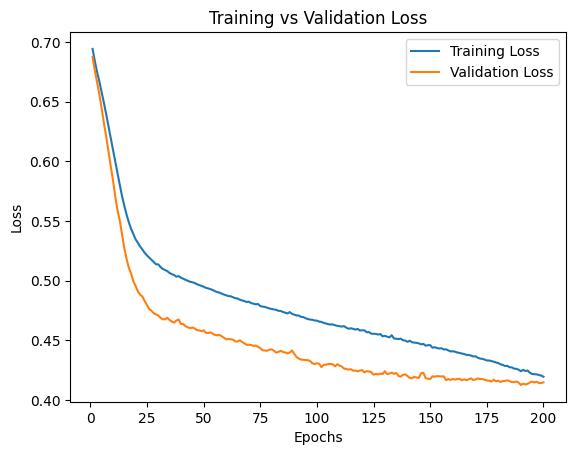

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Mean Squared Error: 0.1322150761514583
Accuracy: 0.8020833333333334


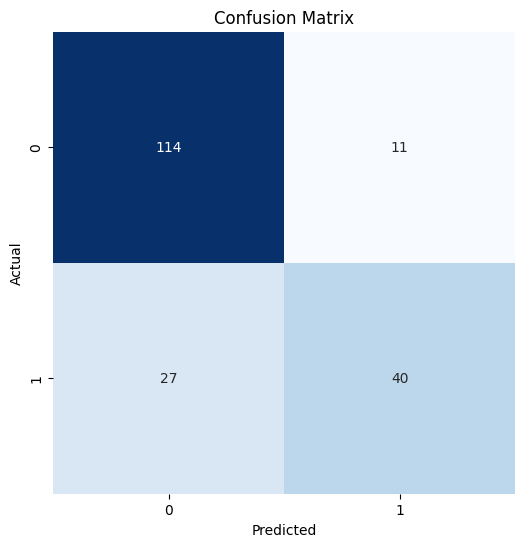

In [1]:
# ============================================================
# NEURAL NETWORK: DIABETES CLASSIFICATION
# ============================================================
# This version improves accuracy by:
# 1. Using the correct loss function (binary cross-entropy)
# 2. Simplifying the network (reduces overfitting)
# 3. Adding validation data
# 4. Using early stopping to prevent overtraining
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

# Keras (Neural Network)
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.callbacks import EarlyStopping

# =========================
# 2. LOAD AND CLEAN DATA
# =========================

# Load dataset
pima = pd.read_excel("Chapter_07-diabetes.xlsx")

# Convert all data to numeric type
pima = pima.astype(float)

# =========================
# 3. DEFINE FEATURES (X) AND TARGET (y)
# =========================

# Input variables (features)
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']
X = pima[feature_cols]

# Output variable (0 = no diabetes, 1 = diabetes)
y = pima['outcome']

# =========================
# 4. SPLIT DATA INTO TRAINING AND TESTING
# =========================

# 75% training data, 25% testing data
# random_state ensures results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=16
)

# =========================
# 5. SCALE THE INPUT DATA
# =========================

# Neural networks perform better when inputs are scaled

# IMPORTANT:
# Fit scaler ONLY on training data (to avoid data leakage)
scaler = StandardScaler()
scaler.fit(X_train)

# Apply transformation
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 6. BUILD THE NEURAL NETWORK
# =========================

# Create a sequential model (layers added one after another)
model = Sequential()

# Define input layer explicitly
model.add(Input(shape=(7,)))

# First hidden layer
model.add(Dense(8, activation='relu'))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Third hidden layer
model.add(Dense(8, activation='relu'))

# Output layer (binary classification → sigmoid)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
# Binary cross-entropy is the correct loss for classification
model.compile(
    loss='binary_crossentropy',
    optimizer='adam'
)

# Show model structure
model.summary()

# =========================
# 7. TRAIN THE MODEL
# =========================

# Early stopping prevents overfitting:
# Training stops when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',          # watch validation loss
    patience=20,                # wait 20 epochs before stopping
    restore_best_weights=True   # keep best model
)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    validation_split=0.2,       # 20% of training data used for validation
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 8. PLOT TRAINING PERFORMANCE
# =========================

# Extract loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# Plot training vs validation loss
plt.figure()
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# =========================
# 9. MAKE PREDICTIONS
# =========================

# Predict probabilities (values between 0 and 1)
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities to class labels (0 or 1)
# Threshold = 0.5
y_pred = (y_pred_prob >= 0.5).astype(int)

# =========================
# 10. EVALUATE MODEL PERFORMANCE
# =========================

# Mean Squared Error (for comparison with earlier models)
mse = mean_squared_error(y_test, y_pred_prob)

# Accuracy (main classification metric)
accuracy = accuracy_score(y_test, y_pred)

# Confusion matrix
conf_m = confusion_matrix(y_test, y_pred)

# =========================
# 11. DISPLAY RESULTS
# =========================

print("Mean Squared Error:", mse)
print("Accuracy:", accuracy)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_m, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()